In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
data_dir = '.\\dataset\\cropped'

In [3]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('dataset/cropped')

In [4]:
list(data_dir.glob('*/*.png'))[:5]

[WindowsPath('dataset/cropped/che_guevara_images/che_guevara_images1.png'),
 WindowsPath('dataset/cropped/che_guevara_images/che_guevara_images10.png'),
 WindowsPath('dataset/cropped/che_guevara_images/che_guevara_images11.png'),
 WindowsPath('dataset/cropped/che_guevara_images/che_guevara_images12.png'),
 WindowsPath('dataset/cropped/che_guevara_images/che_guevara_images13.png')]

In [5]:
image_count = len(list(data_dir.glob('*/*.png')))
print(image_count)

56


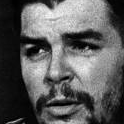

In [6]:
che_guevara = list(data_dir.glob('che_guevara_images/*'))
PIL.Image.open(str(che_guevara[1]))

In [7]:
World_leaders_images_dict = {
    'che_guevara': list(data_dir.glob('che_guevara_images/*')),
    'churchill': list(data_dir.glob('churchill_images/*')),
    'hitler': list(data_dir.glob('hitler_images/*')),
    'roosevelt': list(data_dir.glob('roosevelt_images/*')),
    'stalin': list(data_dir.glob('stalin_images/*')),
}

In [8]:
World_leaders_labels_dict = {
    'che_guevara': 0,
    'churchill': 1,
    'hitler': 2,
    'roosevelt': 3,
    'stalin': 4,
}

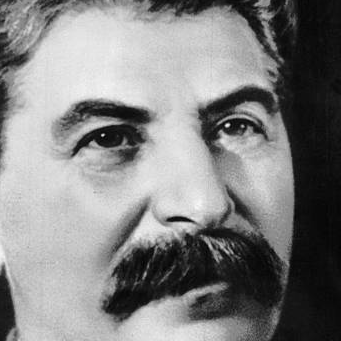

In [9]:
PIL.Image.open(str(World_leaders_images_dict['stalin'][7]))

In [10]:
image = cv2.imread(str(World_leaders_images_dict['stalin'][0]))
image.shape

(286, 286, 3)

In [11]:
X, y = [], []

for leader_name, images in World_leaders_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(World_leaders_labels_dict[leader_name])

In [12]:
X = np.array(X)
y = np.array(y)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [14]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [15]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)              

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.1190 - loss: 1.9931
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2619 - loss: 1.7133
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3571 - loss: 1.5800
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2857 - loss: 1.5382
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2857 - loss: 1.4930
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5952 - loss: 1.4102
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6905 - loss: 1.3394
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7143 - loss: 1.2225
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5952 - loss: 1.1457
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7143 - loss: 0.9810
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8095 - loss: 0.7945
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8571 - lo

In [16]:
model.evaluate(X_test_scaled,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.5714 - loss: 2.4314


[2.431420087814331, 0.5714285969734192]

In [17]:
predictions = model.predict(X_test_scaled)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


array([[10.423277  , -5.5282426 ,  3.1504593 ,  9.923524  , -3.0590186 ],
       [11.252187  , -4.109327  ,  2.363242  ,  2.6091208 ,  2.7837758 ],
       [ 6.742581  , -6.522495  ,  4.1153936 , 14.025762  ,  2.561298  ],
       [ 3.662357  , -3.1213343 ,  3.8216536 ,  9.198143  ,  0.1269156 ],
       [-1.1624023 , 11.682847  , -2.4380805 ,  6.8672595 , -2.4039488 ],
       [ 6.863267  , -0.1385758 ,  5.3828955 ,  6.780332  ,  2.4100678 ],
       [ 4.9815083 , -0.6206045 ,  3.8215659 , 11.464454  , -0.08767065],
       [ 9.497456  , -2.735385  ,  7.154961  ,  8.253685  , -0.7913349 ],
       [ 1.5555705 ,  0.28895664,  9.239735  , 10.04094   , -0.2894009 ],
       [ 7.5311475 ,  2.2607458 , 10.656112  , 12.543321  ,  5.474665  ],
       [ 4.6312976 , -3.3824503 ,  6.428507  ,  3.2481651 , 10.301183  ],
       [17.312971  ,  0.30727863,  0.2700893 , -1.5273601 , 11.194952  ],
       [ 3.4546037 , -1.7043865 , 11.476041  , 10.629806  ,  3.8271224 ],
       [ 3.714889  , 15.19984   , -1.7

In [18]:
score = tf.nn.softmax(predictions[1])
np.argmax(score)

0

In [19]:
y_test[1]

0

In [20]:
data_augmentation = keras.Sequential(
  [
 
    keras.layers.RandomFlip("horizontal", 
                           input_shape=(180, 
                                      180,
                                      3)),
    
    keras.layers.RandomRotation(0.1),
    
    keras.layers.RandomZoom(0.1),
  ]
)

C:\Users\ulise\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


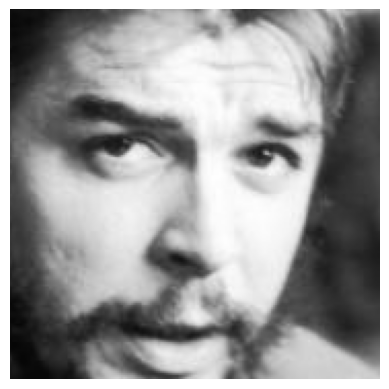

In [21]:
plt.axis('off')
plt.imshow(X[0])

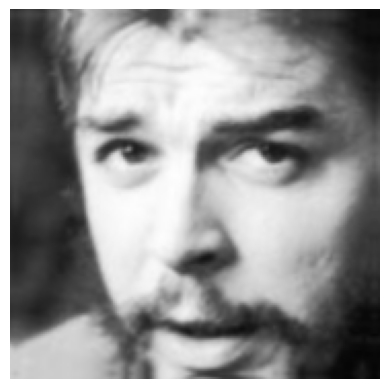

In [22]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [23]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)    

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.2381 - loss: 1.7082
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.1905 - loss: 1.8107
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.1429 - loss: 1.6072
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3095 - loss: 1.5649
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2619 - loss: 1.5792
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5000 - loss: 1.5158
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.2381 - loss: 1.5222
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2381 - loss: 1.5124
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3810 - loss: 1.4538
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3571 - loss: 1.4143
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.4762 - loss: 1.3491
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.4524 - lo

In [24]:
model.evaluate(X_test_scaled,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.4286 - loss: 2.2534


[2.2533698081970215, 0.4285714328289032]

In [26]:
import tensorflow_hub as hub
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [27]:
X, y = [], []

for leader_name, images in World_leaders_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(World_leaders_labels_dict[leader_name])

In [28]:
X = np.array(X)
y = np.array(y)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [30]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [36]:

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV2

num_classes = 5

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10
)

# Fine tuning
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_finetune = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=5
)

loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", accuracy)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.1905 - loss: 2.2347 - val_accuracy: 0.2143 - val_loss: 1.8549
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step - accuracy: 0.2857 - loss: 1.7867 - val_accuracy: 0.2143 - val_loss: 1.9366
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 479ms/step - accuracy: 0.3571 - loss: 1.4555 - val_accuracy: 0.2143 - val_loss: 1.7110
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step - accuracy: 0.5714 - loss: 1.0399 - val_accuracy: 0.2143 - val_loss: 1.7004
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 462ms/step - accuracy: 0.5476 - loss: 1.1443 - val_accuracy: 0.2857 - val_loss: 1.7204
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - accuracy: 0.5476 - loss: 1.0899 - val_accuracy: 0.2857 - val_loss: 1.6850
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step - accuracy: 0.7143 - loss: 0.8877 - val_accuracy: 0.4286 - val_loss: 1.6958
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step - accuracy: 0.7857 - loss: 0.6585 - val_accuracy: 0.3571 - val_loss: 1.